# MODELO DE TAMIZAJE DE TEA (Q-CHAT-10) — VERSIÓN 2

**Objetivo:** entrenar un modelo de Machine Learning que estime el riesgo de Trastorno del Espectro Autista (TEA) a partir de las 10 preguntas del Q-CHAT-10 que responden los padres en la plataforma TEAnimo, y **validarlo contra diagnósticos clínicos reales**.

**Cambios respecto a la versión 1 (`desarrollo_modelo_ml.ipynb`):**

| Aspecto | Versión 1 | Versión 2 |
|---|---|---|
| Datos de entrenamiento | CSV de Kaggle (1985 filas) con columnas alteradas y ~930 filas fabricadas | Datasets públicos originales: Nueva Zelanda (Thabtah, 2018) + Arabia Saudita |
| Validación | Test aleatorio del mismo CSV | **Test externo con diagnóstico clínico** (Polonia, ADOS-2 / ADI-R / DSM-5) |
| Variables del modelo | 20 variables (ítems, suma, comorbilidades, PCA, sexo…) | Ítems A1–A10 (+ edad, si aporta) |
| Preprocesamiento | Escalado, PCA y selección antes del split | Todo dentro de un `Pipeline`, ajustado solo con train |
| Sexo | Usado en el modelo y fijado a 0 en el backend | Fuera del modelo; solo para evaluar sesgos |
| Comorbilidades y antecedente familiar | Dentro del modelo | Fuera del modelo; se usan en la capa de reglas clínicas y en el agente de IA |

**Fuentes de datos (carpeta `data/raw/`):**

| Archivo | Origen | n | Edad | Etiqueta |
|---|---|---|---|---|
| `nz_toddler_autism_2018.csv` | Thabtah (2018), Kaggle "Autism Screening for Toddlers" | 1054 | 12–36 meses | Regla Q-CHAT-10 (suma ≥ 4) |
| `saudi_toddler_autism.csv` | Kaggle "ASD Screening Data for Toddlers in Saudi Arabia" | 506 | 12–36 meses | Regla Q-CHAT-10 (suma ≥ 4) |
| `polish_qchat_mendeley.sav` | Niedźwiecka et al. (2020), Mendeley Data | 252 | 18–24 meses | **Diagnóstico clínico** |
| `dataset_anterior_kaggle.csv` | CSV usado en la versión 1 (solo para la auditoría de la sección 1.1) | 1985 | — | — |

## Preparación

In [1]:
import json, warnings, platform
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import joblib

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (roc_auc_score, recall_score, precision_score, accuracy_score, f1_score,
                             confusion_matrix, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from scipy.stats import chi2_contingency, mannwhitneyu
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

SEED = 42
DATA = Path("../data/raw")
MODELS = Path("../models/v2")
MODELS.mkdir(parents=True, exist_ok=True)

ITEMS = [f"A{i}" for i in range(1, 11)]
print("scikit-learn", sklearn.__version__, "| python", platform.python_version())

scikit-learn 1.6.1 | python 3.11.15


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. ANÁLISIS EXPLORATORIO DE DATOS

## 1.1. Justificación del cambio de dataset

Antes de empezar, dejamos documentado por qué no se usa el CSV de la versión 1. Lo comparamos fila por fila con el dataset original de Nueva Zelanda.

In [2]:
old = pd.read_csv(DATA / "dataset_anterior_kaggle.csv")
nz_raw = pd.read_csv(DATA / "nz_toddler_autism_2018.csv")
old.columns = [c.strip() for c in old.columns]
old_items = [c for c in old.columns if c[:1] == "A" and c[1:2].isdigit()]
old["suma_A"] = old[old_items].sum(axis=1)

# Las primeras 1054 filas del CSV anterior son el dataset de Nueva Zelanda
bloque_a = old.iloc[:1054]
low = lambda s: s.astype(str).str.strip().str.lower()
comparacion = pd.DataFrame({
    "Columna": ["A1–A10", "Ethnicity", "Target", "Sex", "Family_mem_with_ASD", "Who_completed_the_test", "Jaundice"],
    "% filas idénticas al original": [
        (nz_raw[ITEMS].values == bloque_a[old_items].values).all(axis=1).mean(),
        (low(nz_raw["Ethnicity"]) == low(bloque_a["Ethnicity"])).mean(),
        (low(nz_raw["Class/ASD Traits "]) == low(bloque_a["ASD_traits"])).mean(),
        (low(nz_raw["Sex"]) == low(bloque_a["Sex"]).str[0]).mean(),
        (low(nz_raw["Family_mem_with_ASD"]) == low(bloque_a["Family_mem_with_ASD"])).mean(),
        (low(nz_raw["Who completed the test"]) == low(bloque_a["Who_completed_the_test"])).mean(),
        (low(nz_raw["Jaundice"]) == low(bloque_a["Jaundice"])).mean(),
    ],
})
comparacion["% filas idénticas al original"] = (comparacion["% filas idénticas al original"] * 100).round(1)
comparacion

,Columna,% filas idénticas al original
0,A1–A10,100.0
1,Ethnicity,100.0
2,Target,100.0
3,Sex,85.7
4,Family_mem_with_ASD,65.8
5,Who_completed_the_test,46.5
6,Jaundice,29.8


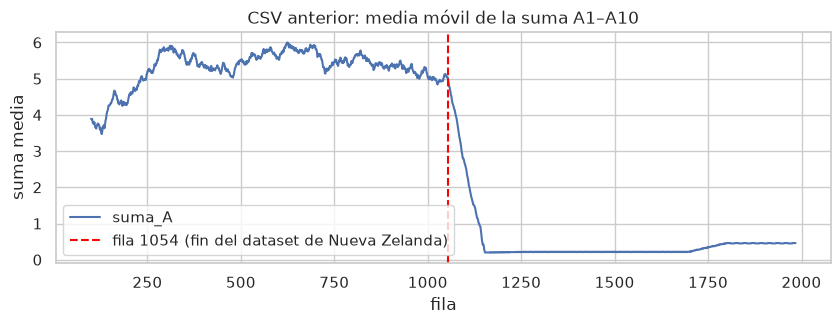

Bloque añadido (filas 1055–1985):
  filas: 931 | filas únicas sin ID: 280
  A1–A9 distintos de 0: 0
  niñas con ASD: 0
ASD_traits       No  Yes
Ethnicity               
Asian             0  131
Middle Eastern  215    0
White European    0  215
asian           175    0
south asian     195    0


In [3]:
# Media de la suma A1–A10 en ventanas de 100 filas: el salto marca el inicio del bloque añadido
fig, ax = plt.subplots(figsize=(10, 3))
old["suma_A"].rolling(100).mean().plot(ax=ax)
ax.axvline(1054, color="red", ls="--", label="fila 1054 (fin del dataset de Nueva Zelanda)")
ax.set(title="CSV anterior: media móvil de la suma A1–A10", xlabel="fila", ylabel="suma media")
ax.legend(); plt.show()

bloque_b = old.iloc[1054:]
print("Bloque añadido (filas 1055–1985):")
print("  filas:", len(bloque_b), "| filas únicas sin ID:", bloque_b.drop(columns=["CASE_NO_PATIENT'S", "suma_A"]).drop_duplicates().shape[0])
print("  A1–A9 distintos de 0:", int(bloque_b[old_items[:9]].sum().sum()))
print("  niñas con ASD:", int(((bloque_b["Sex"] == "F") & (bloque_b["ASD_traits"] == "Yes")).sum()))
print(pd.crosstab(bloque_b["Ethnicity"], bloque_b["ASD_traits"]))

**Conclusión 1.1.** El CSV anterior contiene las respuestas A1–A10 del dataset de Nueva Zelanda sin cambios, pero:
- la edad, el sexo, la ictericia, el antecedente familiar y "quién respondió" fueron alterados;
- las comorbilidades, CARS y SRS no existen en el original;
- las filas 1055–1985 tienen el cuestionario vacío (A1–A9 = 0) y su etiqueta queda determinada por la forma en que está escrita la etnia.

Por eso en esta versión usamos directamente los archivos originales.

## 1.2. Carga y armonización de las fuentes

Las tres fuentes usan el Q-CHAT-10 con el mismo orden de preguntas que el formulario de TEAnimo (preguntas 3 a 12):

| Variable | Pregunta en TEAnimo | Ítem del Q-CHAT completo (Polonia) |
|---|---|---|
| A1 | ¿Tu hijo te mira cuando lo llamas por su nombre? | 1 |
| A2 | ¿Qué tan fácil es lograr contacto visual con tu hijo? | 2 |
| A3 | ¿Tu hijo señala para indicar que quiere algo? | 5 |
| A4 | ¿Tu hijo señala para compartir interés contigo? | 6 |
| A5 | ¿Tu hijo finge? | 9 |
| A6 | ¿Tu hijo sigue con la mirada hacia donde tú estás mirando? | 10 |
| A7 | ¿Tu hijo muestra señales de querer consolar? | 15 |
| A8 | ¿Cómo describirías las primeras palabras de tu hijo? | 17 |
| A9 | ¿Tu hijo usa gestos simples? | 19 |
| A10 | ¿Tu hijo se queda mirando fijamente a la nada? | 25 |

El dataset polaco trae cada ítem codificado de 0 a 4 en el orden de las opciones (el ítem 25 ya viene invertido). La puntuación oficial del Q-CHAT-10, que es la misma que usa `Forms.jsx`, equivale a **valor ≥ 2 → 1 punto** en los 10 ítems.

In [4]:
# Nueva Zelanda
nz = pd.DataFrame({
    **{a: nz_raw[a] for a in ITEMS},
    "Edad_Meses": nz_raw["Age_Mons"],
    "Sexo": low(nz_raw["Sex"]).map({"m": "M", "f": "F"}),
    "Antecedente_Familiar": low(nz_raw["Family_mem_with_ASD"]).map({"yes": 1, "no": 0}),
    "Asd_Traits": (low(nz_raw["Class/ASD Traits "]) == "yes").astype(int),
    "Fuente": "Nueva Zelanda",
})

# Arabia Saudita
sa_raw = pd.read_csv(DATA / "saudi_toddler_autism.csv")
sa = pd.DataFrame({
    **{a: sa_raw[a] for a in ITEMS},
    "Edad_Meses": sa_raw["Age"],
    "Sexo": sa_raw["Gender"].map({"Male": "M", "Female": "F"}),
    "Antecedente_Familiar": sa_raw["Family member with ASD history"].map({"Yes": 1, "No": 0}),
    "Asd_Traits": sa_raw["Class"].astype(int),
    "Fuente": "Arabia Saudita",
})

# Polonia (Q-CHAT completo de 25 ítems -> Q-CHAT-10)
pl_raw, pl_meta = pyreadstat.read_sav(DATA / "polish_qchat_mendeley.sav")
MAPEO_PL = {"A1": 1, "A2": 2, "A3": 5, "A4": 6, "A5": 9, "A6": 10, "A7": 15, "A8": 17, "A9": 19, "A10": 25}
pl = pd.DataFrame({
    **{a: (pl_raw[f"qchat{q}recode"] >= 2).astype(int) for a, q in MAPEO_PL.items()},
    "Edad_Meses": pl_raw["age"],
    "Sexo": pl_raw["sex"].map({1.0: "M", 2.0: "F"}),
    "Antecedente_Familiar": pl_raw["sibling_withASD"],
    "Asd_Traits": (pl_raw["group"] == 1).astype(int),   # 1 = ASD, 7 = control
    "Fuente": "Polonia",
})

for nombre, d in [("Nueva Zelanda", nz), ("Arabia Saudita", sa), ("Polonia", pl)]:
    print(f"{nombre:15s} {d.shape} | ASD={d.Asd_Traits.sum()} / No={len(d) - d.Asd_Traits.sum()}")

Nueva Zelanda   (1054, 15) | ASD=728 / No=326
Arabia Saudita  (506, 15) | ASD=341 / No=165
Polonia         (252, 15) | ASD=135 / No=117


In [5]:
# Verificación: en NZ y Arabia Saudita la etiqueta es exactamente la regla del Q-CHAT-10
for nombre, d in [("Nueva Zelanda", nz), ("Arabia Saudita", sa)]:
    regla = (d[ITEMS].sum(axis=1) >= 4).astype(int)
    print(f"{nombre}: etiqueta == (suma A1–A10 >= 4) en {(regla == d.Asd_Traits).mean():.1%} de filas")
print("Polonia: la etiqueta es el diagnóstico clínico (no depende de la suma)")

Nueva Zelanda: etiqueta == (suma A1–A10 >= 4) en 100.0% de filas
Arabia Saudita: etiqueta == (suma A1–A10 >= 4) en 100.0% de filas
Polonia: la etiqueta es el diagnóstico clínico (no depende de la suma)


## 1.3. Evaluación del supuesto de completitud de la información

In [6]:
completitud = pd.concat([d.isna().sum().rename(n) for n, d in [("Nueva Zelanda", nz), ("Arabia Saudita", sa), ("Polonia", pl)]], axis=1)
completitud[completitud.sum(axis=1) > 0]

,Nueva Zelanda,Arabia Saudita,Polonia
Antecedente_Familiar,0,0,22


Solo hay nulos en `Antecedente_Familiar` del dataset polaco. Esa variable no entra al modelo, así que no se imputa.

## 1.4. Tratamiento y limpieza de datos

In [7]:
# Duplicados: en NZ y Arabia Saudita no hay ID, así que filas idénticas son el mismo patrón de respuestas.
# Se eliminan solo dentro del conjunto de entrenamiento para que no haya copias entre train y test interno.
train_full = pd.concat([nz, sa], ignore_index=True)
print("NZ + Arabia Saudita:", len(train_full))
print("Duplicados exactos (todas las columnas salvo Fuente):", train_full.drop(columns="Fuente").duplicated().sum())
train_full = train_full.loc[~train_full.drop(columns="Fuente").duplicated()].reset_index(drop=True)
print("Tras eliminar duplicados:", len(train_full), "| ASD =", train_full.Asd_Traits.sum(), "| No =", (1 - train_full.Asd_Traits).sum())

NZ + Arabia Saudita: 1560
Duplicados exactos (todas las columnas salvo Fuente): 290
Tras eliminar duplicados: 1270 | ASD = 914 | No = 356


## 1.5. Resumen global de las variables de estudio

### 1.5.1. Variables cuantitativas

Edad_Meses                                           \
                    count  mean  std   min   25%   50%   75%   max   
Fuente                                                               
Arabia Saudita      390.0  23.9  8.1  12.0  17.0  24.0  32.0  36.0   
Nueva Zelanda       880.0  27.8  7.7  12.0  23.0  30.0  36.0  36.0   
Polonia             252.0  21.1  2.1  18.0  19.0  21.0  23.0  24.0   

               Suma_QCHAT10                                      
                      count mean  std  min  25%  50%  75%   max  
Fuente                                                           
Arabia Saudita        390.0  5.5  2.8  0.0  3.0  6.0  8.0  10.0  
Nueva Zelanda         880.0  5.3  2.7  0.0  3.0  5.0  7.0  10.0  
Polonia               252.0  3.8  3.1  0.0  1.0  3.0  6.0  10.0

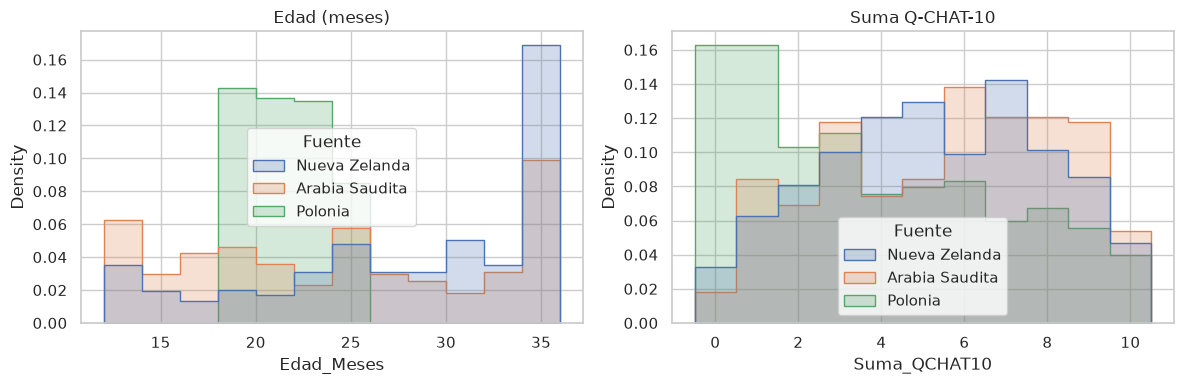

In [8]:
todos = pd.concat([train_full, pl], ignore_index=True)
todos["Suma_QCHAT10"] = todos[ITEMS].sum(axis=1)
display(todos.groupby("Fuente")[["Edad_Meses", "Suma_QCHAT10"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=todos, x="Edad_Meses", hue="Fuente", element="step", stat="density", common_norm=False, ax=axes[0])
sns.histplot(data=todos, x="Suma_QCHAT10", hue="Fuente", element="step", stat="density", common_norm=False, discrete=True, ax=axes[1])
axes[0].set_title("Edad (meses)"); axes[1].set_title("Suma Q-CHAT-10")
plt.tight_layout(); plt.show()

### 1.5.2. Variables cualitativas

In [9]:
resumen = todos.groupby("Fuente").agg(
    n=("Asd_Traits", "size"),
    pct_ASD=("Asd_Traits", "mean"),
    pct_varones=("Sexo", lambda s: (s == "M").mean()),
    pct_antecedente=("Antecedente_Familiar", "mean"),
)
display((resumen.assign(**{c: resumen[c] * 100 for c in ["pct_ASD", "pct_varones", "pct_antecedente"]})).round(1))

items_pct = todos.groupby(["Fuente", "Asd_Traits"])[ITEMS].mean().T.round(2)
items_pct

,n,pct_ASD,pct_varones,pct_antecedente
Fuente,,,,
Arabia Saudita,390,71.0,31.8,27.9
Nueva Zelanda,880,72.4,69.9,16.8
Polonia,252,53.6,62.3,10.9


Fuente     Arabia Saudita       Nueva Zelanda       Polonia      
Asd_Traits              0     1             0     1       0     1
A1                   0.25  0.71          0.22  0.72    0.06  0.53
A2                   0.06  0.66          0.12  0.57    0.02  0.48
A3                   0.18  0.65          0.11  0.51    0.06  0.61
A4                   0.18  0.66          0.16  0.66    0.12  0.68
A5                   0.22  0.70          0.12  0.68    0.22  0.73
A6                   0.08  0.75          0.18  0.74    0.15  0.54
A7                   0.21  0.68          0.30  0.82    0.43  0.84
A8                   0.24  0.75          0.16  0.58    0.11  0.44
A9                   0.11  0.73          0.08  0.66    0.09  0.52
A10                  0.47  0.70          0.45  0.63    0.10  0.46

## 1.6. Análisis de correlación y asociación

### 1.6.1. Ítems del Q-CHAT-10 frente al diagnóstico clínico (Polonia)

In [10]:
filas = []
for a in ITEMS:
    tabla = pd.crosstab(pl[a], pl.Asd_Traits)
    chi2, p, _, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    cramer = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    filas.append({"Ítem": a, "% ASD que puntúa": pl.loc[pl.Asd_Traits == 1, a].mean() * 100,
                  "% control que puntúa": pl.loc[pl.Asd_Traits == 0, a].mean() * 100,
                  "V de Cramér": cramer, "p-valor": p})
asoc = pd.DataFrame(filas).round(3).sort_values("V de Cramér", ascending=False)
asoc

,Ítem,% ASD que puntúa,% control que puntúa,V de Cramér,p-valor
2,A3,60.741,5.983,0.563,0.0
3,A4,68.148,11.966,0.560,0.0
1,A2,48.148,1.709,0.515,0.0
4,A5,73.333,22.222,0.502,0.0
0,A1,53.333,5.983,0.500,0.0
8,A9,51.852,8.547,0.455,0.0
6,A7,84.444,42.735,0.428,0.0
5,A6,54.074,14.530,0.403,0.0
9,A10,45.926,10.256,0.382,0.0
7,A8,43.704,11.111,0.351,0.0


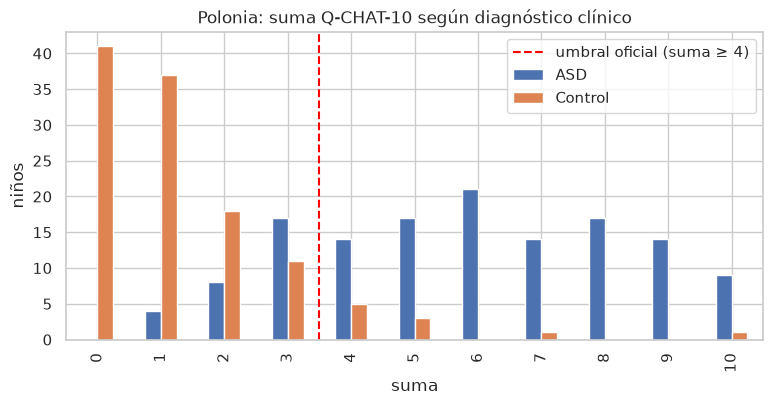

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
suma_pl = pl[ITEMS].sum(axis=1)
pd.crosstab(suma_pl, pl.Asd_Traits.map({1: "ASD", 0: "Control"})).plot(kind="bar", ax=ax)
ax.axvline(3.5, color="red", ls="--", label="umbral oficial (suma ≥ 4)")
ax.set(title="Polonia: suma Q-CHAT-10 según diagnóstico clínico", xlabel="suma", ylabel="niños"); ax.legend()
plt.show()

### 1.6.2. Edad, sexo y antecedente familiar frente al target

In [12]:
for nombre, d in [("NZ + Arabia Saudita", train_full), ("Polonia", pl)]:
    u = mannwhitneyu(d.loc[d.Asd_Traits == 1, "Edad_Meses"], d.loc[d.Asd_Traits == 0, "Edad_Meses"])
    print(f"{nombre}: mediana edad ASD={d.loc[d.Asd_Traits==1,'Edad_Meses'].median()} | No={d.loc[d.Asd_Traits==0,'Edad_Meses'].median()} | Mann-Whitney p={u.pvalue:.3f}")
    for v in ["Sexo", "Antecedente_Familiar"]:
        t = pd.crosstab(d[v], d.Asd_Traits, normalize="index").round(3) * 100
        print(f"  % ASD según {v}:", t[1].to_dict())

NZ + Arabia Saudita: mediana edad ASD=28.0 | No=26.0 | Mann-Whitney p=0.130
  % ASD según Sexo: {'F': 69.3, 'M': 73.9}
  % ASD según Antecedente_Familiar: {0: 70.7, 1: 77.0}
Polonia: mediana edad ASD=20.0 | No=22.0 | Mann-Whitney p=0.012
  % ASD según Sexo: {'F': 41.099999999999994, 'M': 61.1}
  % ASD según Antecedente_Familiar: {0.0: 53.2, 1.0: 100.0}


**Conclusiones de la sección 1:**
- En Nueva Zelanda y Arabia Saudita la etiqueta es la regla del Q-CHAT-10. Un modelo entrenado con ellos aprende esa regla; su capacidad real solo se puede medir con el dataset polaco.
- En Polonia todas las preguntas se asocian con el diagnóstico clínico, así que la señal es real y no un artefacto del etiquetado.
- La edad del dataset polaco solo va de 18 a 24 meses: su efecto no se puede validar clínicamente fuera de ese rango.

# 2. PREPROCESAMIENTO DE DATOS

## 2.1. Creación de nuevas variables

Creamos una copia de cada conjunto y aplicamos las mismas transformaciones a todos.

1) Grupo etario. Como el Q-CHAT-10 aplica a niños pequeños, los grupos se definen en meses.

In [13]:
def agregar_variables(d):
    d = d.copy()
    d["Grupo_Etario"] = pd.cut(d["Edad_Meses"], bins=[0, 18, 24, 30, 36], labels=["12-18m", "19-24m", "25-30m", "31-36m"])
    return d

2) Perfiles de habilidades. Seguimos los pesos validados con especialistas en la versión 1, **sin las comorbilidades**, que ya no forman parte del modelo. Los pesos de los ítems se reescalan para que sumen 100 %.

🟦 **Habilidades comunicativas**

| Variable | Peso v1 | Peso v2 | Justificación (v1) |
|---|---|---|---|
| A3 (señalar para pedir) | 20 % | 33.3 % | Intencionalidad comunicativa activa |
| A8 (primeras palabras) | 20 % | 33.3 % | Desarrollo del lenguaje expresivo |
| A9 (gestos simples) | 20 % | 33.3 % | Comunicación no verbal temprana |
| Speech_Delay_Language_Disorder | 25 % | — | Comorbilidad: pasa a la capa de reglas clínicas |
| Learning_Disorder | 15 % | — | Comorbilidad: pasa a la capa de reglas clínicas |

🟩 **Interacción social**

| Variable | Peso v1 | Peso v2 | Justificación (v1) |
|---|---|---|---|
| A1 (respuesta al nombre) | 10 % | 13.3 % | Marcador inicial de atención conjunta |
| A2 (contacto visual) | 10 % | 13.3 % | Conexión social temprana |
| A4 (compartir interés) | 10 % | 13.3 % | Reciprocidad social |
| A5 (juego simbólico) | 15 % | 20 % | Socialización avanzada |
| A6 (seguir la mirada) | 15 % | 20 % | Atención compartida |
| A7 (respuesta emocional) | 15 % | 20 % | Empatía básica |
| Social_Behavioural_Issues | 20 % | — | Comorbilidad: pasa a la capa de reglas clínicas |
| Anxiety_Disorder | 5 % | — | Comorbilidad: pasa a la capa de reglas clínicas |

La regla del perfil clínico se mantiene: **Mixto** si la diferencia entre ambos porcentajes es menor a 10 puntos; si no, el perfil con mayor porcentaje.

In [14]:
PESOS_COMUNICACION = {"A3": 0.20, "A8": 0.20, "A9": 0.20}
PESOS_SOCIAL = {"A1": 0.10, "A2": 0.10, "A4": 0.10, "A5": 0.15, "A6": 0.15, "A7": 0.15}

def porcentaje_ponderado(d, pesos):
    return np.average(d[list(pesos)], axis=1, weights=list(pesos.values())) * 100   # np.average reescala los pesos

def clasificar_perfil(com, soc):
    if abs(com - soc) < 10:
        return "Mixto"
    return "Comunicativo" if com > soc else "Interacción social"

def agregar_perfiles(d):
    d = d.copy()
    d["Communication_Issues_%"] = porcentaje_ponderado(d, PESOS_COMUNICACION).round(2)
    d["Social_Interaction_Issues_%"] = porcentaje_ponderado(d, PESOS_SOCIAL).round(2)
    d["Clinical_Profile"] = [clasificar_perfil(c, s) for c, s in zip(d["Communication_Issues_%"], d["Social_Interaction_Issues_%"])]
    return d

train_full = agregar_perfiles(agregar_variables(train_full))
pl = agregar_perfiles(agregar_variables(pl))
pl[ITEMS + ["Communication_Issues_%", "Social_Interaction_Issues_%", "Clinical_Profile", "Asd_Traits"]].head(10)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Communication_Issues_%,Social_Interaction_Issues_%,Clinical_Profile,Asd_Traits
0,1,1,1,1,1,1,1,1,1,0,100.00,100.00,Mixto,1
1,0,0,0,1,1,0,1,0,0,1,0.00,53.33,Interacción social,1
2,0,0,1,1,0,0,1,0,1,0,66.67,33.33,Comunicativo,1
3,1,1,1,1,1,1,1,0,1,0,66.67,100.00,Interacción social,1
4,0,0,1,0,1,0,1,0,1,1,66.67,40.00,Comunicativo,1
5,1,1,0,0,1,1,1,0,0,0,0.00,86.67,Interacción social,1
6,1,1,1,1,1,1,1,1,1,0,100.00,100.00,Mixto,1
7,0,0,1,0,1,1,1,0,1,1,66.67,60.00,Mixto,1
8,0,0,1,0,1,1,1,0,0,0,33.33,60.00,Interacción social,1
9,0,0,0,0,0,0,1,0,0,1,0.00,20.00,Interacción social,1


## 2.2. Análisis de nuevas variables en relación al target

### 2.2.1. Variables cuantitativas creadas

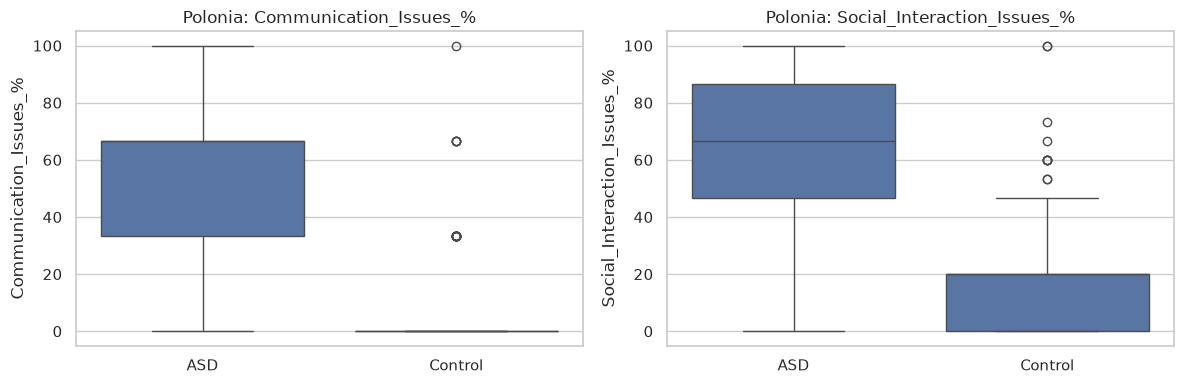

Communication_Issues_% | AUC frente al diagnóstico clínico: 0.833
Social_Interaction_Issues_% | AUC frente al diagnóstico clínico: 0.906


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, v in zip(axes, ["Communication_Issues_%", "Social_Interaction_Issues_%"]):
    sns.boxplot(data=pl, x=pl.Asd_Traits.map({1: "ASD", 0: "Control"}), y=v, ax=ax)
    ax.set(title=f"Polonia: {v}", xlabel="")
plt.tight_layout(); plt.show()
for v in ["Communication_Issues_%", "Social_Interaction_Issues_%"]:
    print(v, "| AUC frente al diagnóstico clínico:", round(roc_auc_score(pl.Asd_Traits, pl[v]), 3))

### 2.2.2. Variables cualitativas creadas

In [16]:
display(pd.crosstab(pl.Clinical_Profile, pl.Asd_Traits.map({1: "ASD", 0: "Control"}), margins=True))
display(pd.crosstab(train_full.Grupo_Etario, train_full.Asd_Traits, normalize="index").round(3) * 100)

Asd_Traits,ASD,Control,All
Clinical_Profile,,,
Comunicativo,31,14,45
Interacción social,73,53,126
Mixto,31,50,81
All,135,117,252


Asd_Traits,0,1
Grupo_Etario,,
12-18m,29.8,70.2
19-24m,31.3,68.7
25-30m,26.0,74.0
31-36m,26.5,73.5


Los perfiles separan bien a los niños con y sin TEA, pero son combinaciones lineales de los mismos ítems A1–A10. Por eso se evalúan como variante del modelo (sección 3.1), pero su uso principal es **explicar el resultado al padre y orientar la recomendación de terapias** en la aplicación.

> Nota para la app: un niño que no puntúa en ningún ítem (0 % y 0 %) queda como "Mixto" por la regla de la versión 1. En la aplicación conviene mostrar el perfil solo cuando el riesgo no es bajo.

## 2.3. Depuración de variables para el modelado

| Variable | Decisión | Motivo |
|---|---|---|
| A1–A10 | **Entra al modelo** | Preguntas validadas del Q-CHAT-10 que responde el padre |
| Edad_Meses | **Se evalúa** (sección 4.4) | Pedido explícito; se descarta si no aporta |
| Communication_Issues_%, Social_Interaction_Issues_% | Se evalúan como variante | Derivadas de A1–A10 (redundantes) |
| Clinical_Profile, Grupo_Etario | Fuera del modelo | Uso descriptivo y en la app |
| Suma Q-CHAT-10 | Fuera del modelo | Es la suma exacta de A1–A10; se usa como regla de referencia |
| Sexo | Fuera del modelo | Solo para evaluar sesgos (sección 4.6) |
| Antecedente_Familiar, comorbilidades | Fuera del modelo | Pasan a la capa de reglas clínicas y al agente de IA |

## 2.4. Encoding de variables categóricas

No hace falta: los ítems ya son binarios (0/1) y la edad es numérica.

## 2.5. Escalamiento/Normalización de datos

El escalado (`StandardScaler`) va **dentro de un `Pipeline`** en los modelos que lo necesitan (SVM, Regresión Logística, KNN). Así se ajusta solo con los datos de entrenamiento de cada fold y se exporta junto con el modelo; el backend ya no necesita mínimos y máximos escritos a mano.

Tampoco se usa **PCA**: sus componentes eran combinaciones de los mismos ítems y se ajustaban antes del split.

# 3. MODELADO

## 3.1. División de los datos y creación de variantes del dataset

| Conjunto | Datos | Uso |
|---|---|---|
| **Train** | 80 % de NZ + Arabia Saudita | Ajuste de hiperparámetros con validación cruzada (5 folds) |
| **Test interno** | 20 % de NZ + Arabia Saudita | Comprobar que el modelo reproduce la regla del Q-CHAT-10 |
| **Validación clínica** | 50 % de Polonia | Elegir el modelo final y el umbral de decisión |
| **Test clínico** | 50 % de Polonia | **Evaluación final, se usa una sola vez** |

Los splits se estratifican por target (y por fuente en NZ + Arabia Saudita).

In [17]:
train, test_int = train_test_split(train_full, test_size=0.20, random_state=SEED,
                                   stratify=train_full.Fuente + "_" + train_full.Asd_Traits.astype(str))
val_cli, test_cli = train_test_split(pl, test_size=0.50, random_state=SEED, stratify=pl.Asd_Traits)

for n, d in [("Train", train), ("Test interno", test_int), ("Validación clínica", val_cli), ("Test clínico", test_cli)]:
    print(f"{n:20s} n={len(d):4d} | ASD={d.Asd_Traits.sum():4d} ({d.Asd_Traits.mean():.1%})")

VARIANTES = {
    "Qchat": ITEMS,
    "Qchat_Edad": ITEMS + ["Edad_Meses"],
    "Qchat_Edad_Perfiles": ITEMS + ["Edad_Meses", "Communication_Issues_%", "Social_Interaction_Issues_%"],
}

Train                n=1016 | ASD= 732 (72.0%)
Test interno         n= 254 | ASD= 182 (71.7%)
Validación clínica   n= 126 | ASD=  68 (54.0%)
Test clínico         n= 126 | ASD=  67 (53.2%)


### 3.1.1. Qchat: ítems A1–A10

### 3.1.2. Qchat_Edad: ítems A1–A10 + edad en meses

### 3.1.3. Qchat_Edad_Perfiles: ítems + edad + porcentajes de habilidades

## 3.2. Selección y justificación de modelos

### 3.2.1. Modelo de referencia (baseline): regla oficial del Q-CHAT-10
Suma de A1–A10 ≥ 4. Cualquier modelo de ML debe compararse contra esta regla, que es la que se usa en la práctica clínica.

### 3.2.2. Modelos de boosting
AdaBoost, Gradient Boosting, XGBoost, LightGBM y CatBoost: combinan árboles débiles y capturan interacciones entre ítems.

### 3.2.3. Benchmark: Random Forest

### 3.2.4. Modelos extra
SVM (kernel lineal y radial), Regresión Logística y KNN.

### 3.2.5. Criterio de selección (definido antes de ver resultados)
1. Se calcula el AUC de cada modelo en la **validación clínica**.
2. Entre los modelos a menos de 0.01 del mejor AUC, se elige el **más simple e interpretable**, en este orden: Regresión Logística → SVM lineal → KNN → Random Forest → SVM radial → AdaBoost → Gradient Boosting → LightGBM → XGBoost → CatBoost.
3. La variante con edad o perfiles solo se prefiere si mejora el AUC de validación clínica en al menos 0.005.

In [18]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados, modelos = [], {}

def metricas(y, prob, umbral=0.5):
    pred = (prob >= umbral).astype(int)
    return {"AUC": roc_auc_score(y, prob), "Sensibilidad": recall_score(y, pred),
            "Especificidad": recall_score(1 - y, 1 - pred), "Precisión": precision_score(y, pred, zero_division=0),
            "Accuracy": accuracy_score(y, pred), "F1": f1_score(y, pred)}

def entrenar(nombre, estimador, grid, escalar=False):
    for variante, cols in VARIANTES.items():
        pasos = ([("scaler", StandardScaler())] if escalar else []) + [("modelo", estimador)]
        gs = GridSearchCV(Pipeline(pasos), {f"modelo__{k}": v for k, v in grid.items()},
                          cv=CV, scoring="roc_auc", n_jobs=-1)
        gs.fit(train[cols], train.Asd_Traits)
        clave = f"{nombre}_{variante}"
        modelos[clave] = gs.best_estimator_
        fila = {"Modelo": clave, "Algoritmo": nombre, "Variante": variante, "CV_AUC_train": gs.best_score_,
                "Mejores_parametros": {k.replace("modelo__", ""): v for k, v in gs.best_params_.items()}}
        fila.update({f"{k}_test_int": v for k, v in metricas(test_int.Asd_Traits, gs.predict_proba(test_int[cols])[:, 1]).items()})
        fila["AUC_val_clinica"] = roc_auc_score(val_cli.Asd_Traits, gs.predict_proba(val_cli[cols])[:, 1])
        resultados.append(fila)
        print(f"{clave:40s} CV_AUC={gs.best_score_:.3f} | AUC test interno={fila['AUC_test_int']:.3f} | AUC val. clínica={fila['AUC_val_clinica']:.3f}")

## 3.3. Entrenamiento

### 3.3.1. AdaBoost

In [19]:
entrenar("AdaBoost", AdaBoostClassifier(random_state=SEED),
         {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 0.5, 1.0]},
         escalar=False)

AdaBoost_Qchat                           CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.905


AdaBoost_Qchat_Edad                      CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.905


AdaBoost_Qchat_Edad_Perfiles             CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.912


### 3.3.2. Gradient Boosting

In [20]:
entrenar("Gradient Boosting", GradientBoostingClassifier(random_state=SEED),
         {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
         escalar=False)

Gradient Boosting_Qchat                  CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.912


Gradient Boosting_Qchat_Edad             CV_AUC=0.999 | AUC test interno=1.000 | AUC val. clínica=0.910


Gradient Boosting_Qchat_Edad_Perfiles    CV_AUC=0.999 | AUC test interno=1.000 | AUC val. clínica=0.908


### 3.3.3. XGBoost

In [21]:
entrenar("XGBoost", XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=1),
         {"n_estimators": [100, 300], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
         escalar=False)

XGBoost_Qchat                            CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.911


XGBoost_Qchat_Edad                       CV_AUC=0.999 | AUC test interno=1.000 | AUC val. clínica=0.912


XGBoost_Qchat_Edad_Perfiles              CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.913


### 3.3.4. LightGBM

In [22]:
entrenar("LightGBM", LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=1),
         {"n_estimators": [100, 300], "learning_rate": [0.05, 0.1], "num_leaves": [7, 15]},
         escalar=False)

LightGBM_Qchat                           CV_AUC=0.999 | AUC test interno=1.000 | AUC val. clínica=0.907


LightGBM_Qchat_Edad                      CV_AUC=0.999 | AUC test interno=1.000 | AUC val. clínica=0.910


LightGBM_Qchat_Edad_Perfiles             CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.914


### 3.3.5. CatBoost

In [23]:
entrenar("CatBoost", CatBoostClassifier(random_state=SEED, verbose=0, thread_count=1),
         {"iterations": [200, 400], "learning_rate": [0.05, 0.1], "depth": [3, 4]},
         escalar=False)

CatBoost_Qchat                           CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.910


CatBoost_Qchat_Edad                      CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.909


CatBoost_Qchat_Edad_Perfiles             CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.910


### 3.3.6. Random Forest

In [24]:
entrenar("Random Forest", RandomForestClassifier(random_state=SEED, n_jobs=1),
         {"n_estimators": [200, 400], "max_depth": [3, 5, None], "min_samples_leaf": [1, 3]},
         escalar=False)

Random Forest_Qchat                      CV_AUC=0.996 | AUC test interno=0.997 | AUC val. clínica=0.874


Random Forest_Qchat_Edad                 CV_AUC=0.995 | AUC test interno=0.997 | AUC val. clínica=0.902


Random Forest_Qchat_Edad_Perfiles        CV_AUC=0.999 | AUC test interno=1.000 | AUC val. clínica=0.890


### 3.3.7. SVM Lineal

In [25]:
entrenar("SVM Lineal", SVC(kernel='linear', probability=True, random_state=SEED),
         {"C": [0.01, 0.1, 1, 10]},
         escalar=True)

SVM Lineal_Qchat                         CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.903


SVM Lineal_Qchat_Edad                    CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.899
SVM Lineal_Qchat_Edad_Perfiles           CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.907


### 3.3.8. SVM Radial

In [26]:
entrenar("SVM Radial", SVC(kernel='rbf', probability=True, random_state=SEED),
         {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]},
         escalar=True)

SVM Radial_Qchat                         CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.901


SVM Radial_Qchat_Edad                    CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.905


SVM Radial_Qchat_Edad_Perfiles           CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.907


### 3.3.9. Regresión Logística

In [27]:
entrenar("Regresión Logística", LogisticRegression(max_iter=5000),
         {"C": [0.01, 0.1, 1, 10]},
         escalar=True)

Regresión Logística_Qchat                CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.904


Regresión Logística_Qchat_Edad           CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.904


Regresión Logística_Qchat_Edad_Perfiles  CV_AUC=1.000 | AUC test interno=1.000 | AUC val. clínica=0.905


### 3.3.10. KNN

In [28]:
entrenar("KNN", KNeighborsClassifier(),
         {"n_neighbors": [5, 11, 21, 31], "weights": ["uniform", "distance"]},
         escalar=True)

KNN_Qchat                                CV_AUC=0.999 | AUC test interno=1.000 | AUC val. clínica=0.856
KNN_Qchat_Edad                           CV_AUC=0.998 | AUC test interno=0.998 | AUC val. clínica=0.871


KNN_Qchat_Edad_Perfiles                  CV_AUC=0.998 | AUC test interno=0.999 | AUC val. clínica=0.868


# 4. EVALUACIÓN

## 4.1. Comparación de modelos

### 4.1.1. Regla oficial del Q-CHAT-10 (referencia)

In [29]:
def evaluar_regla(d, corte=4):
    s = d[ITEMS].sum(axis=1)
    m = metricas(d.Asd_Traits, s, umbral=corte)
    m["AUC"] = roc_auc_score(d.Asd_Traits, s)
    return m

pd.DataFrame({f"Regla suma ≥ {c} — {n}": evaluar_regla(d, c) for c in [3, 4]
              for n, d in [("test interno", test_int), ("validación clínica", val_cli)]}).T.round(3)

,AUC,Sensibilidad,Especificidad,Precisión,Accuracy,F1
Regla suma ≥ 3 — test interno,1.000,1.000,0.625,0.871,0.894,0.931
Regla suma ≥ 3 — validación clínica,0.909,0.897,0.793,0.836,0.849,0.865
Regla suma ≥ 4 — test interno,1.000,1.000,1.000,1.000,1.000,1.000
Regla suma ≥ 4 — validación clínica,0.909,0.779,0.897,0.898,0.833,0.835


### 4.1.2. Todos los modelos

In [30]:
res = pd.DataFrame(resultados)
cols_vista = ["Modelo", "CV_AUC_train", "AUC_test_int", "Sensibilidad_test_int", "Especificidad_test_int", "AUC_val_clinica"]
res[cols_vista].sort_values("AUC_val_clinica", ascending=False).round(3)

,Modelo,CV_AUC_train,AUC_test_int,Sensibilidad_test_int,Especificidad_test_int,AUC_val_clinica
11,LightGBM_Qchat_Edad_Perfiles,1.000,1.000,1.000,1.000,0.914
8,XGBoost_Qchat_Edad_Perfiles,1.000,1.000,1.000,1.000,0.913
7,XGBoost_Qchat_Edad,0.999,1.000,1.000,0.986,0.912
3,Gradient Boosting_Qchat,1.000,1.000,1.000,0.986,0.912
2,AdaBoost_Qchat_Edad_Perfiles,1.000,1.000,1.000,1.000,0.912
6,XGBoost_Qchat,1.000,1.000,1.000,0.986,0.911
10,LightGBM_Qchat_Edad,0.999,1.000,1.000,0.972,0.910
14,CatBoost_Qchat_Edad_Perfiles,1.000,1.000,1.000,1.000,0.910
4,Gradient Boosting_Qchat_Edad,0.999,1.000,1.000,0.944,0.910
12,CatBoost_Qchat,1.000,1.000,1.000,1.000,0.910


El AUC en validación cruzada y en el test interno es cercano a 1 en casi todos los modelos. **No es una fuga de datos:** en NZ y Arabia Saudita la etiqueta es la regla del Q-CHAT-10, y los modelos la reproducen. La métrica que importa es la de la **validación clínica**.

### 4.1.3. Según variante del dataset

In [31]:
res.pivot_table(index="Algoritmo", columns="Variante", values="AUC_val_clinica").round(3)

Variante,Qchat,Qchat_Edad,Qchat_Edad_Perfiles
Algoritmo,,,
AdaBoost,0.905,0.905,0.912
CatBoost,0.910,0.909,0.910
Gradient Boosting,0.912,0.910,0.908
KNN,0.856,0.871,0.868
LightGBM,0.907,0.910,0.914
Random Forest,0.874,0.902,0.890
Regresión Logística,0.904,0.904,0.905
SVM Lineal,0.903,0.899,0.907
SVM Radial,0.901,0.905,0.907


### 4.1.4. Según algoritmo

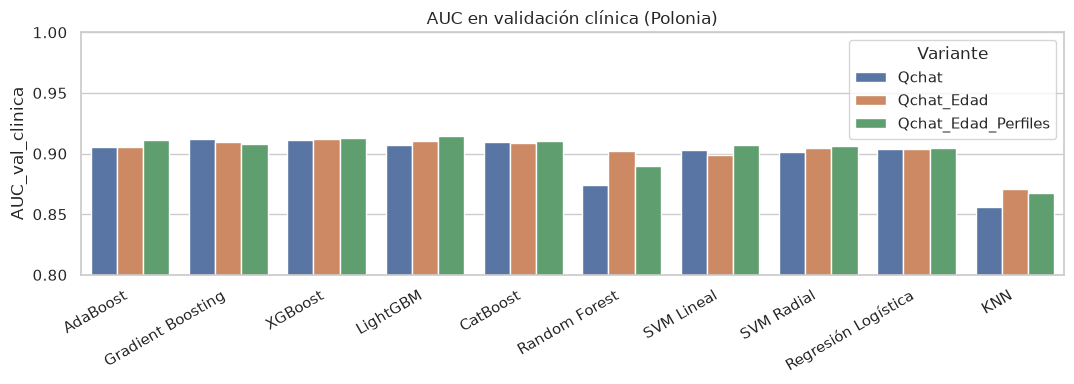

In [32]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=res, x="Algoritmo", y="AUC_val_clinica", hue="Variante", ax=ax)
ax.set(ylim=(0.8, 1.0), title="AUC en validación clínica (Polonia)", xlabel="")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

### 4.1.5. TOP 3 mejores modelos

In [33]:
res.sort_values("AUC_val_clinica", ascending=False).head(3)[["Modelo", "AUC_val_clinica", "Mejores_parametros"]]

,Modelo,AUC_val_clinica,Mejores_parametros
11,LightGBM_Qchat_Edad_Perfiles,0.914300,"{'learning_rate': 0.1, 'n_estimators': 300, 'n..."
8,XGBoost_Qchat_Edad_Perfiles,0.912652,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
7,XGBoost_Qchat_Edad,0.911765,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."


## 4.2. Modelo elegido

In [34]:
ORDEN_SIMPLICIDAD = ["Regresión Logística", "SVM Lineal", "KNN", "Random Forest", "SVM Radial", "AdaBoost",
                     "Gradient Boosting", "LightGBM", "XGBoost", "CatBoost"]

# 1) Variante: la más simple salvo que otra mejore el AUC clínico en >= 0.005
mejor_por_variante = res.groupby("Variante")["AUC_val_clinica"].max()
variante_final = "Qchat"
for v in ["Qchat_Edad", "Qchat_Edad_Perfiles"]:
    if mejor_por_variante[v] >= mejor_por_variante[variante_final] + 0.005:
        variante_final = v
print("AUC clínico máximo por variante:", mejor_por_variante.round(3).to_dict())
print("Variante elegida:", variante_final)

# 2) Algoritmo: el más simple dentro de 0.01 del mejor AUC clínico de esa variante
cand = res[res.Variante == variante_final].copy()
cand = cand[cand.AUC_val_clinica >= cand.AUC_val_clinica.max() - 0.01]
cand["orden"] = cand.Algoritmo.map(ORDEN_SIMPLICIDAD.index)
elegido = cand.sort_values("orden").iloc[0]
MODELO_FINAL = elegido.Modelo
FEATURES = VARIANTES[variante_final]
pipe_final = modelos[MODELO_FINAL]
print("Candidatos:", cand.sort_values("orden").Modelo.tolist())
print("Modelo elegido:", MODELO_FINAL, "| parámetros:", elegido.Mejores_parametros)

AUC clínico máximo por variante: {'Qchat': 0.912, 'Qchat_Edad': 0.912, 'Qchat_Edad_Perfiles': 0.914}
Variante elegida: Qchat
Candidatos: ['Regresión Logística_Qchat', 'SVM Lineal_Qchat', 'AdaBoost_Qchat', 'Gradient Boosting_Qchat', 'LightGBM_Qchat', 'XGBoost_Qchat', 'CatBoost_Qchat']
Modelo elegido: Regresión Logística_Qchat | parámetros: {'C': 0.1}


## 4.3. Calibración de probabilidades

El modelo se entrenó con etiquetas que son una regla exacta, así que sus probabilidades salen casi siempre cerca de 0 o de 1 y no se pueden leer como "porcentaje de riesgo". Para que el número tenga sentido clínico, se **calibra con la validación clínica** (regresión logística sobre la salida del modelo, método *sigmoid*: solo 2 parámetros, adecuado para 126 niños). La calibración no cambia el orden de los niños, así que el AUC es el mismo.

> **Advertencia:** la muestra polaca tiene un 54 % de niños con TEA (diseño casos-controles). En la población general la prevalencia es mucho menor, así que la probabilidad calibrada **sobreestima** el riesgo real. En la aplicación conviene mostrar un **nivel de riesgo** (bajo, moderado, alto) y no el porcentaje exacto.

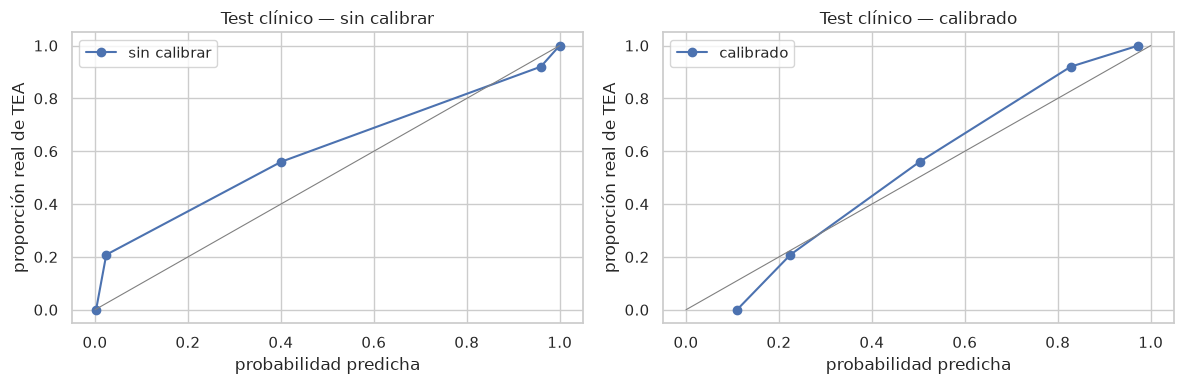

Probabilidades sin calibrar (percentiles 10/50/90): [0.001 0.344 1.   ]
Probabilidades calibradas  (percentiles 10/50/90): [0.096 0.493 0.973]


In [35]:
modelo_cal = CalibratedClassifierCV(FrozenEstimator(pipe_final), method="sigmoid").fit(val_cli[FEATURES], val_cli.Asd_Traits)

prob_sin = pipe_final.predict_proba(test_cli[FEATURES])[:, 1]
prob_con = modelo_cal.predict_proba(test_cli[FEATURES])[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nombre, p) in zip(axes, [("sin calibrar", prob_sin), ("calibrado", prob_con)]):
    frac, media = calibration_curve(test_cli.Asd_Traits, p, n_bins=5, strategy="quantile")
    ax.plot(media, frac, "o-", label=nombre); ax.plot([0, 1], [0, 1], color="grey", lw=0.8)
    ax.set(title=f"Test clínico — {nombre}", xlabel="probabilidad predicha", ylabel="proporción real de TEA"); ax.legend()
plt.tight_layout(); plt.show()
print("Probabilidades sin calibrar (percentiles 10/50/90):", np.percentile(prob_sin, [10, 50, 90]).round(3))
print("Probabilidades calibradas  (percentiles 10/50/90):", np.percentile(prob_con, [10, 50, 90]).round(3))

## 4.4. Selección del umbral de decisión

En tamizaje es peor no detectar a un niño con TEA (falso negativo) que derivar a evaluación a uno sin TEA (falso positivo). El umbral se elige en la **validación clínica** con este criterio, definido de antemano:

> **Máxima especificidad posible manteniendo una sensibilidad ≥ 0.90.**

Umbral elegido: 0.325


,umbral,sensibilidad,especificidad
1,0.992,0.059,0.983
3,0.983,0.176,0.983
5,0.942,0.368,0.983
7,0.799,0.574,0.966
9,0.760,0.676,0.948
11,0.687,0.691,0.931
13,0.648,0.721,0.914
15,0.526,0.794,0.897
17,0.501,0.809,0.862
19,0.481,0.838,0.845


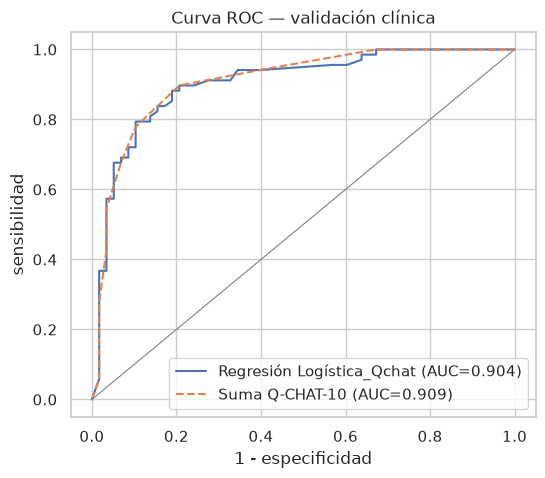

In [36]:
prob_val = modelo_cal.predict_proba(val_cli[FEATURES])[:, 1]
fpr, tpr, thr = roc_curve(val_cli.Asd_Traits, prob_val)
curva = pd.DataFrame({"umbral": thr, "sensibilidad": tpr, "especificidad": 1 - fpr})
curva = curva[(curva.umbral <= 1) & (curva.umbral >= 0)]
ok = curva[curva.sensibilidad >= 0.90]
UMBRAL = float(ok.sort_values(["especificidad", "umbral"], ascending=[False, False]).iloc[0].umbral)
print(f"Umbral elegido: {UMBRAL:.3f}")
display(curva.iloc[::max(1, len(curva) // 15)].round(3))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{MODELO_FINAL} (AUC={roc_auc_score(val_cli.Asd_Traits, prob_val):.3f})")
s = val_cli[ITEMS].sum(axis=1); fr, tr, _ = roc_curve(val_cli.Asd_Traits, s)
ax.plot(fr, tr, ls="--", label=f"Suma Q-CHAT-10 (AUC={roc_auc_score(val_cli.Asd_Traits, s):.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=0.8)
ax.set(xlabel="1 - especificidad", ylabel="sensibilidad", title="Curva ROC — validación clínica"); ax.legend()
plt.show()

## 4.5. Evaluación final en el test clínico

Esta es la **única vez** que se usa el test clínico. Se reportan intervalos de confianza al 95 % con bootstrap (2000 remuestreos).

In [37]:
def bootstrap_ic(y, prob, umbral, n=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    y, prob = np.asarray(y), np.asarray(prob)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].min() == y[idx].max():
            continue
        vals.append(metricas(y[idx], prob[idx], umbral))
    vals = pd.DataFrame(vals)
    return vals.quantile(0.025), vals.quantile(0.975)

prob_test = modelo_cal.predict_proba(test_cli[FEATURES])[:, 1]
suma_test = test_cli[ITEMS].sum(axis=1)
filas = {}
for nombre, prob, umbral in [(f"{MODELO_FINAL} (umbral {UMBRAL:.3f})", prob_test, UMBRAL),
                             (f"{MODELO_FINAL} (umbral 0.5)", prob_test, 0.5),
                             ("Regla oficial suma ≥ 4", suma_test, 4),
                             ("Regla suma ≥ 3", suma_test, 3)]:
    m = metricas(test_cli.Asd_Traits, prob, umbral)
    if "Regla" in nombre:
        m["AUC"] = roc_auc_score(test_cli.Asd_Traits, suma_test)
    lo, hi = bootstrap_ic(test_cli.Asd_Traits, prob, umbral)
    filas[nombre] = {k: f"{m[k]:.3f} [{lo[k]:.2f}–{hi[k]:.2f}]" for k in ["AUC", "Sensibilidad", "Especificidad", "Precisión", "Accuracy"]}
METRICAS_TEST = metricas(test_cli.Asd_Traits, prob_test, UMBRAL)
pd.DataFrame(filas).T

,AUC,Sensibilidad,Especificidad,Precisión,Accuracy
Regresión Logística_Qchat (umbral 0.325),0.960 [0.93–0.98],0.925 [0.85–0.98],0.831 [0.73–0.92],0.861 [0.78–0.93],0.881 [0.83–0.94]
Regresión Logística_Qchat (umbral 0.5),0.960 [0.93–0.98],0.851 [0.75–0.94],0.898 [0.82–0.97],0.905 [0.83–0.97],0.873 [0.81–0.93]
Regla oficial suma ≥ 4,0.964 [0.94–0.99],0.791 [0.69–0.89],0.932 [0.86–0.98],0.930 [0.86–0.98],0.857 [0.80–0.91]
Regla suma ≥ 3,0.964 [0.94–0.99],0.925 [0.85–0.98],0.847 [0.75–0.93],0.873 [0.79–0.94],0.889 [0.83–0.94]


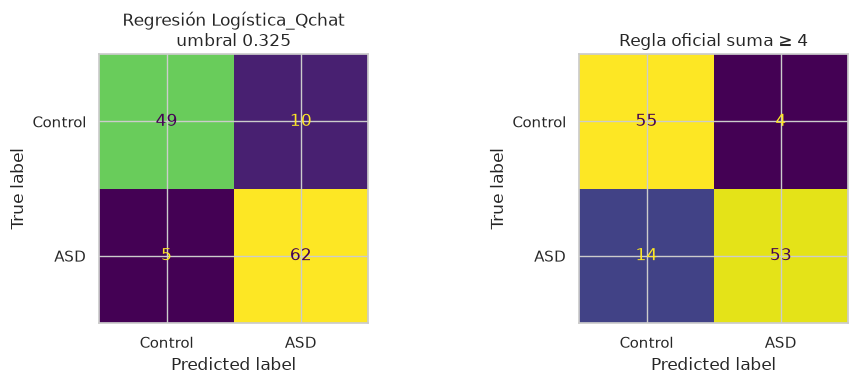

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(test_cli.Asd_Traits, (prob_test >= UMBRAL).astype(int)),
                       display_labels=["Control", "ASD"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"{MODELO_FINAL}\numbral {UMBRAL:.3f}")
ConfusionMatrixDisplay(confusion_matrix(test_cli.Asd_Traits, (suma_test >= 4).astype(int)),
                       display_labels=["Control", "ASD"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Regla oficial suma ≥ 4")
plt.tight_layout(); plt.show()

## 4.6. Interpretabilidad

### 4.6.1. Explicabilidad (SHAP)

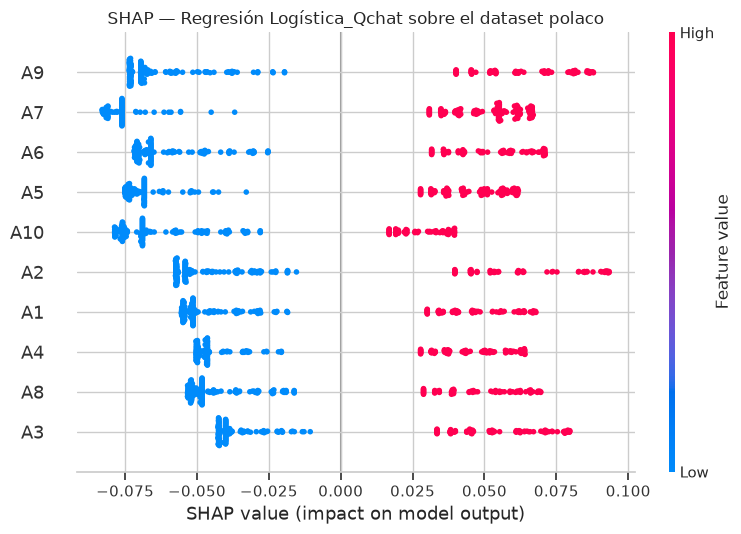

In [39]:
X_bg = train[FEATURES].sample(200, random_state=SEED)
explainer = shap.Explainer(lambda X: modelo_cal.predict_proba(pd.DataFrame(X, columns=FEATURES))[:, 1], X_bg)
shap_vals = explainer(pl[FEATURES], silent=True)
shap.plots.beeswarm(shap_vals, max_display=len(FEATURES), show=False)
plt.title(f"SHAP — {MODELO_FINAL} sobre el dataset polaco"); plt.tight_layout(); plt.show()

### 4.6.2. Importancia de variables y decisión sobre la edad

In [40]:
imp = permutation_importance(modelo_cal, val_cli[FEATURES], val_cli.Asd_Traits, scoring="roc_auc",
                             n_repeats=50, random_state=SEED)
importancia = pd.Series(imp.importances_mean, index=FEATURES).sort_values(ascending=False)
display(importancia.round(4).to_frame("Caída de AUC al permutar"))

auc_edad = res[res.Algoritmo == elegido.Algoritmo].set_index("Variante")["AUC_val_clinica"]
print("AUC en validación clínica del algoritmo elegido según variante:")
print(auc_edad.round(4).to_dict())
print("¿Edad en el modelo final?", "Edad_Meses" in FEATURES)

,Caída de AUC al permutar
A2,0.0232
A10,0.0120
A7,0.0110
A9,0.0095
A3,0.0093
A5,0.0079
A6,0.0068
A4,0.0057
A1,0.0055
A8,0.0010


AUC en validación clínica del algoritmo elegido según variante:
{'Qchat': 0.9037, 'Qchat_Edad': 0.9038, 'Qchat_Edad_Perfiles': 0.9045}
¿Edad en el modelo final? False


## 4.7. Evaluación de sesgos

In [41]:
def por_grupo(d, prob, umbral, col):
    filas = []
    for g, sub in d.assign(prob=prob).groupby(col, observed=True):
        if sub.Asd_Traits.nunique() < 2:
            continue
        m = metricas(sub.Asd_Traits, sub.prob, umbral)
        filas.append({col: g, "n": len(sub), "ASD": int(sub.Asd_Traits.sum()),
                      **{k: round(m[k], 3) for k in ["AUC", "Sensibilidad", "Especificidad"]}})
    return pd.DataFrame(filas)

prob_pl = modelo_cal.predict_proba(pl[FEATURES])[:, 1]
print("Polonia completo (diagnóstico clínico), por sexo:")
display(por_grupo(pl, prob_pl, UMBRAL, "Sexo"))
print("NZ + Arabia Saudita (test interno), por sexo y grupo etario:")
prob_int = modelo_cal.predict_proba(test_int[FEATURES])[:, 1]
display(por_grupo(test_int, prob_int, UMBRAL, "Sexo"))
display(por_grupo(test_int, prob_int, UMBRAL, "Grupo_Etario"))

Polonia completo (diagnóstico clínico), por sexo:


,Sexo,n,ASD,AUC,Sensibilidad,Especificidad
0,F,95,39,0.971,0.949,0.839
1,M,157,96,0.905,0.906,0.721


NZ + Arabia Saudita (test interno), por sexo y grupo etario:


,Sexo,n,ASD,AUC,Sensibilidad,Especificidad
0,F,100,69,1.0,1.0,0.516
1,M,154,113,1.0,1.0,0.634


,Grupo_Etario,n,ASD,AUC,Sensibilidad,Especificidad
0,12-18m,51,37,1.0,1.0,0.857
1,19-24m,55,40,1.0,1.0,0.600
2,25-30m,64,50,1.0,1.0,0.429
3,31-36m,84,55,1.0,1.0,0.517


El análisis por sexo en Polonia usa los 252 niños (validación + test) solo con fines descriptivos, ya que en cada mitad hay muy pocas niñas.

# 5. PRUEBAS

## 5.1. Perfiles clínicos en niños con diagnóstico

In [42]:
display(pd.crosstab(pl.Clinical_Profile, pl.Asd_Traits.map({1: "ASD", 0: "Control"}), normalize="columns").round(3) * 100)
display(pl.groupby(pl.Asd_Traits.map({1: "ASD", 0: "Control"}))[["Communication_Issues_%", "Social_Interaction_Issues_%"]].mean().round(1))

Asd_Traits,ASD,Control
Clinical_Profile,,
Comunicativo,23.0,12.0
Interacción social,54.1,45.3
Mixto,23.0,42.7


,Communication_Issues_%,Social_Interaction_Issues_%
Asd_Traits,,
ASD,52.1,65.0
Control,8.5,18.5


## 5.2. Ingreso de registros y predicción desde el formulario de TEAnimo

Esta función reproduce la puntuación de `Forms.jsx`: para las preguntas 3 a 11 (A1–A9) suma 1 si se elige la opción 3, 4 o 5 (índice ≥ 2); para la pregunta 12 (A10) suma 1 si se elige la opción 1, 2 o 3 (índice ≤ 2). El formulario pide la edad en años, así que se convierte a meses.

In [43]:
def respuestas_a_features(respuestas):
    # respuestas: lista con el índice (0-4) elegido en las preguntas 3 a 12 del formulario, más la edad en años
    items = [1 if r >= 2 else 0 for r in respuestas["qchat"][:9]] + [1 if respuestas["qchat"][9] <= 2 else 0]
    fila = dict(zip(ITEMS, items))
    fila["Edad_Meses"] = respuestas["edad_anios"] * 12
    d = agregar_perfiles(pd.DataFrame([fila]))
    return d

def predecir(respuestas):
    d = respuestas_a_features(respuestas)
    prob = float(modelo_cal.predict_proba(d[FEATURES])[:, 1][0])
    return {"probabilidad": round(prob, 3), "riesgo": int(prob >= UMBRAL),
            "suma_qchat10": int(d[ITEMS].sum(axis=1)[0]),
            "communication_%": float(d["Communication_Issues_%"][0]),
            "social_%": float(d["Social_Interaction_Issues_%"][0]),
            "perfil": d["Clinical_Profile"][0]}

ejemplos = {
    "Desarrollo típico": {"qchat": [0, 0, 0, 0, 0, 0, 0, 0, 0, 4], "edad_anios": 2},
    "Señales leves": {"qchat": [1, 1, 2, 1, 1, 2, 1, 1, 1, 3], "edad_anios": 2},
    "Señales sociales": {"qchat": [3, 3, 1, 3, 3, 3, 3, 1, 1, 3], "edad_anios": 2},
    "Señales comunicativas": {"qchat": [1, 1, 4, 1, 1, 1, 1, 4, 4, 3], "edad_anios": 3},
    "Señales marcadas": {"qchat": [4, 4, 4, 4, 4, 4, 4, 4, 4, 0], "edad_anios": 3},
}
pd.DataFrame({k: predecir(v) for k, v in ejemplos.items()}).T

,probabilidad,riesgo,suma_qchat10,communication_%,social_%,perfil
Desarrollo típico,0.096,0,0,0.0,0.0,Mixto
Señales leves,0.303,0,2,33.33,20.0,Comunicativo
Señales sociales,0.89,1,6,0.0,100.0,Interacción social
Señales comunicativas,0.478,1,3,100.0,0.0,Comunicativo
Señales marcadas,0.992,1,10,100.0,100.0,Mixto


# 6. EXPORTACIÓN DEL MODELO

Se reentrena el pipeline elegido con **todo** NZ + Arabia Saudita (train + test interno) y los mismos hiperparámetros, y se vuelve a calibrar con la validación clínica. El umbral es el elegido en la sección 4.4. Se guardan:
- `models/v2/modelo_tamizaje_tea.pkl`: modelo completo de scikit-learn (preprocesamiento + modelo + calibración). Se usa con `predict_proba`.
- `models/v2/metadata.json`: variables, umbral, métricas, pesos de los perfiles y versiones.

In [44]:
from sklearn.base import clone
base_export = clone(pipe_final).fit(train_full[FEATURES], train_full.Asd_Traits)
pipe_export = CalibratedClassifierCV(FrozenEstimator(base_export), method="sigmoid").fit(val_cli[FEATURES], val_cli.Asd_Traits)

# Comprobación: el modelo reentrenado mantiene el rendimiento en el test clínico
prob_export = pipe_export.predict_proba(test_cli[FEATURES])[:, 1]
print("Test clínico con el modelo exportado:", {k: round(float(v), 3) for k, v in metricas(test_cli.Asd_Traits, prob_export, UMBRAL).items()})

joblib.dump(pipe_export, MODELS / "modelo_tamizaje_tea.pkl")
metadata = {
    "modelo": MODELO_FINAL,
    "algoritmo": elegido.Algoritmo,
    "hiperparametros": elegido.Mejores_parametros,
    "features": FEATURES,
    "umbral": round(UMBRAL, 4),
    "criterio_umbral": "máxima especificidad con sensibilidad >= 0.90 en la validación clínica (Polonia, 50%)",
    "calibracion": "sigmoid sobre la validación clínica (Polonia, 50%, prevalencia 54%): la probabilidad sobreestima el riesgo poblacional; mostrar niveles, no el porcentaje exacto",
    "metricas_test_clinico": {k: round(float(v), 4) for k, v in metricas(test_cli.Asd_Traits, prob_export, UMBRAL).items()},
    "metricas_regla_oficial_test_clinico": {k: round(float(v), 4) for k, v in evaluar_regla(test_cli, 4).items()},
    "datos_entrenamiento": {"fuentes": ["Nueva Zelanda (Thabtah 2018)", "Arabia Saudita (Kaggle)"], "n": int(len(train_full))},
    "datos_validacion_clinica": {"fuente": "Polonia (Niedźwiecka et al. 2020)", "n_validacion": int(len(val_cli)), "n_test": int(len(test_cli))},
    "puntuacion_items": "A1-A9: 1 si el índice de la opción >= 2; A10: 1 si el índice <= 2 (igual que Forms.jsx)",
    "edad": "Edad_Meses = edad en años del formulario x 12" if "Edad_Meses" in FEATURES else "no se usa en el modelo",
    "perfiles": {"pesos_comunicacion": PESOS_COMUNICACION, "pesos_social": PESOS_SOCIAL,
                 "regla": "Mixto si |com% - soc%| < 10; si no, el mayor"},
    "rango_validado": "12-36 meses (entrenamiento); 18-24 meses (validación clínica)",
    "versiones": {"python": platform.python_version(), "scikit-learn": sklearn.__version__},
    "fecha": datetime.now().strftime("%Y-%m-%d"),
}
(MODELS / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2))
print(json.dumps(metadata, ensure_ascii=False, indent=2))

Test clínico con el modelo exportado: {'AUC': 0.96, 'Sensibilidad': 0.925, 'Especificidad': 0.847, 'Precisión': 0.873, 'Accuracy': 0.889, 'F1': 0.899}


{
  "modelo": "Regresión Logística_Qchat",
  "algoritmo": "Regresión Logística",
  "hiperparametros": {
    "C": 0.1
  },
  "features": [
    "A1",
    "A2",
    "A3",
    "A4",
    "A5",
    "A6",
    "A7",
    "A8",
    "A9",
    "A10"
  ],
  "umbral": 0.3251,
  "criterio_umbral": "máxima especificidad con sensibilidad >= 0.90 en la validación clínica (Polonia, 50%)",
  "calibracion": "sigmoid sobre la validación clínica (Polonia, 50%, prevalencia 54%): la probabilidad sobreestima el riesgo poblacional; mostrar niveles, no el porcentaje exacto",
  "metricas_test_clinico": {
    "AUC": 0.9598,
    "Sensibilidad": 0.9254,
    "Especificidad": 0.8475,
    "Precisión": 0.8732,
    "Accuracy": 0.8889,
    "F1": 0.8986
  },
  "metricas_regla_oficial_test_clinico": {
    "AUC": 0.964,
    "Sensibilidad": 0.791,
    "Especificidad": 0.9322,
    "Precisión": 0.9298,
    "Accuracy": 0.8571,
    "F1": 0.8548
  },
  "datos_entrenamiento": {
    "fuentes": [
      "Nueva Zelanda (Thabtah 2018)",


## 6.1. Verificación de carga

In [45]:
cargado = joblib.load(MODELS / "modelo_tamizaje_tea.pkl")
meta = json.loads((MODELS / "metadata.json").read_text())
assert np.allclose(cargado.predict_proba(test_cli[meta["features"]])[:, 1], prob_export)
print("OK: el modelo guardado reproduce las mismas probabilidades.")

OK: el modelo guardado reproduce las mismas probabilidades.


# 7. CONCLUSIONES Y LIMITACIONES

## 7.1. Resultados principales

| Método (test clínico, Polonia, n = 126) | AUC | Sensibilidad | Especificidad |
|---|---|---|---|
| **Modelo final: Regresión Logística A1–A10, calibrada, umbral 0.325** | **0.960** [0.93–0.98] | **0.925** [0.85–0.98] | **0.831–0.847** [0.73–0.93] |
| Regla oficial Q-CHAT-10 (suma ≥ 4) | 0.964 | 0.791 [0.69–0.89] | 0.932 [0.86–0.98] |
| Regla suma ≥ 3 | 0.964 | 0.925 | 0.847 |

(La especificidad es 0.831 con el modelo entrenado solo con train y 0.847 con el modelo exportado, reentrenado con todo NZ + Arabia Saudita.)

1. **El modelo detecta 92.5 % de los niños con TEA diagnosticado clínicamente**, frente al 79 % de la regla oficial, a cambio de algo más de falsos positivos (especificidad 0.85 frente a 0.93). Para tamizaje ese intercambio es el adecuado: un falso positivo termina en una evaluación profesional; un falso negativo retrasa la terapia.
2. **El ML no supera a la regla en capacidad de discriminación** (AUC 0.960 frente a 0.964; los intervalos se solapan). En la práctica el modelo es una versión ponderada del Q-CHAT-10 con un punto de corte equivalente a "suma ≥ 3". Lo que aporta es una probabilidad calibrada, un pipeline reproducible y la explicación por pregunta (SHAP).
3. **Las 10 preguntas aportan.** La que más pesa es A2 (contacto visual), seguida de A10 (mirar fijamente a la nada) y A7 (consolar).
4. **La edad se descartó** con el criterio definido de antemano: no mejora el AUC clínico (0.9037 frente a 0.9038). Tampoco lo mejoran los porcentajes de habilidades, que se mantienen para los perfiles de la app.
5. **Los modelos complejos no ganan:** boosting, SVM y Random Forest quedan en el mismo rango (AUC clínico 0.87–0.91), así que se eligió el más simple e interpretable.
6. **Los perfiles validados por especialistas**, recalculados sin comorbilidades, separan bien a los niños con TEA (AUC 0.83 el comunicativo y 0.91 el social) y sirven para orientar las terapias en la app.

## 7.2. Limitaciones

- **Etiquetas de entrenamiento:** en NZ y Arabia Saudita la etiqueta es la regla del Q-CHAT-10, no un diagnóstico. La validación clínica descansa en 252 niños polacos: 126 para elegir modelo, umbral y calibración, y 126 para la evaluación final. Los intervalos de confianza son amplios.
- **Edad:** la validación clínica solo cubre de 18 a 24 meses y el entrenamiento de 12 a 36. El formulario de TEAnimo acepta de 1 a 18 años: **fuera de ese rango el modelo no está validado**.
- **Probabilidad:** está calibrada en una muestra con 54 % de TEA, así que sobreestima el riesgo en la población general. En la app conviene mostrar niveles de riesgo, no el porcentaje.
- **Sesgo por sexo:** en Polonia la especificidad es menor en varones (0.72) que en niñas (0.84): hay más falsos positivos en varones. La sensibilidad es similar (0.91 y 0.95).
- **Población:** no hay niños peruanos en los datos. Antes de usar el modelo en decisiones reales conviene un estudio local con los centros aliados.
- **Perfil "Mixto":** con la regla de la versión 1, un niño sin señales queda como "Mixto". En la app, el perfil solo debe mostrarse cuando el riesgo no es bajo.

## 7.3. Uso en la aplicación

- Cargar `models/v2/modelo_tamizaje_tea.pkl` y leer las variables y el umbral desde `models/v2/metadata.json` (no escribirlos a mano).
- Las comorbilidades (preguntas 13–19) y el antecedente familiar (pregunta 20) no entran al modelo: van a la capa de reglas clínicas y al agente de IA, que también usa la edad para el mensaje (a menor edad, "a tiempo para la intervención temprana"; a mayor edad, mayor urgencia).
- Las consideraciones completas están en `docs/consideraciones_app_tamizaje.md`.